In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
class Bayes:
    """Bayesian heart-deasis classifier"""

    def __init__(self) -> None:
        self.state = None
        self.label2name = {1: "Heart risk", 0: "Health probs"}

    def fit(self, features: pd.DataFrame, labels: npt.ArrayLike) -> None:
        """Gen state of probabilities for Bayesian classifier
        Args:
            features (DataFrame): age, sex, cholesterin, max HR
            labels (ArrayLike): heart-deasiss
        """
        self.state = {}
        for label in labels.unique():
            label_features = features[labels == label]
            self.state[self.label2name[label]] = {}
            for feature in label_features.columns:
                values = label_features[feature]
                if features[feature].nunique() <= 2:
                    self.state[self.label2name[label]][feature] = values.value_counts(normalize=True).to_dict()
                else:
                    self.state[self.label2name[label]][feature] = {"mean": values.mean(), "std": values.std()}
            self.state[self.label2name[label]]["prob"] = (labels == label).mean()

    def predict(self, features: npt.ArrayLike, plot: bool = False) -> npt.NDArray:
        """Predicts heart deasis probability
        Args:
            features (DataFrame): age, sex, cholesterin, max HR
        """
        prob_yes = self.state[self.label2name[1]]["prob"]
        prob_no = self.state[self.label2name[0]]["prob"]
        if plot:
            fig, axs = plt.subplots(1, 4, figsize=(21, 4))

        for idx, (feature, value) in enumerate(features.items()):
            if "mean" in self.state[self.label2name[1]][feature]:
                mean_yes, std_yes = (
                    self.state[self.label2name[1]][feature]["mean"],
                    self.state[self.label2name[1]][feature]["std"],
                )
                mean_no, std_no = (
                    self.state[self.label2name[0]][feature]["mean"],
                    self.state[self.label2name[0]][feature]["std"],
                )
                if plot:
                    self.plot_cont_features(mean_yes, std_yes, mean_no, std_no, value, axs[idx], feature)

                prob_yes *= (1 / (np.sqrt(2 * np.pi) * std_yes)) * np.exp(-0.5 * ((value - mean_yes) / std_yes) ** 2)
                prob_no *= (1 / (np.sqrt(2 * np.pi) * std_no)) * np.exp(-0.5 * ((value - mean_no) / std_no) ** 2)
            else:
                prob_yes *= self.state[self.label2name[1]][feature][int(value)]
                prob_no *= self.state[self.label2name[0]][feature][int(value)]
                if plot:
                    self.plot_disc_features(
                        self.state[self.label2name[1]][feature][int(value)],
                        self.state[self.label2name[0]][feature][int(value)],
                        value,
                        axs[idx],
                        feature,
                    )

        total = prob_yes + prob_no
        return round((prob_yes / total).item(), 4), fig

    def save(self, save_path: Path | str) -> None:
        if isinstance(save_path, Path):
            with save_path.open("w") as file:
                json.dump(self.state, file)
        else:
            with open(save_path, "w") as file:
                json.dump(self.state, file)

    def load(self, state_path: Path | str) -> None:
        if isinstance(state_path, Path):
            with state_path.open("r") as file:
                self.state = json.load(file)
        else:
            with open(state_path) as file:
                self.state = json.load(file)

    def print_state(self) -> None:
        def print_nested(data, indent_level=0):
            # Define the indentation string (2 spaces per level)
            indent = "  " * indent_level

            if isinstance(data, dict):
                for key, value in data.items():
                    print(f"{indent}{key}:")
                    print_nested(value, indent_level + 1)

            elif isinstance(data, list):
                for item in data:
                    # For list items, we just print the value with current indentation
                    # If the item itself is complex (dict/list), recurse; otherwise print raw
                    if isinstance(item, (dict, list)):
                        # If a list contains a dict, we might want a newline or specific handling
                        # Based on your example, simple values are printed directly
                        print_nested(item, indent_level)
                    else:
                        print(f"{indent}{item}")

            else:
                # Base case for primitive values inside lists if not caught above
                print(f"{indent}{round(data, 4)}")

        print_nested(self.state[self.label2name[1]])

    def plot_cont_features(
        self,
        mean_yes: float,
        std_yes: float,
        mean_no: float,
        std_no: float,
        value: int,
        ax: plt.Subplot,
        feature: str,
    ) -> None:
        x_min = min(mean_yes - 3 * std_yes, mean_no - 3 * std_no)
        x_max = max(mean_yes + 3 * std_yes, mean_no + 3 * std_no)
        x = np.linspace(x_min, x_max, 1000)

        y_yes = (1 / (np.sqrt(2 * np.pi) * std_yes)) * np.exp(-0.5 * ((x - mean_yes) / std_yes) ** 2)
        y_no = (1 / (np.sqrt(2 * np.pi) * std_no)) * np.exp(-0.5 * ((x - mean_no) / std_no) ** 2)

        ax.plot(x, y_yes, label="Heart risk", color="red")
        ax.plot(x, y_no, label="Health probs", color="green")
        ax.axvline(value, color="blue", linestyle="--", label=f"Value: {int(value)}")
        ax.set_title(f"{feature}")
        ax.legend(bbox_to_anchor=(0.5, 1.20), loc="upper center", ncol=3)
        ax.grid(True)

    def plot_disc_features(
        self,
        prob_yes,
        prob_no,
        value: int,
        ax: plt.Subplot,
        feature: str,
    ) -> None:
        ax.bar(["Healthy", "Ill"], [prob_no, prob_yes])
        ax.axvline(value, color="blue", linestyle="--", label=f"Value: {int(value)}")
        ax.set_title(f"{feature}")
        ax.legend(bbox_to_anchor=(0.5, 1.20), loc="upper center", ncol=3)
        ax.grid(True)

In [ ]:
data = pd.read_csv("../data/train(1).csv")
X = data[["Sex", "Age", "Cholesterol", "Max HR"]]

y = data["Heart Disease"] == "Presence"

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.1)

b = Bayes()
b.fit(x_train, y_train)

In [ ]:
b.print_state()

Sex:
  1:
    0.8864
  0:
    0.1136
Age:
  mean:
    56.0841
  std:
    7.7701
Cholesterol:
  mean:
    248.112
  std:
    32.9146
Max HR:
  mean:
    143.4827
  std:
    19.7209
prob:
  0.4485


0.6022

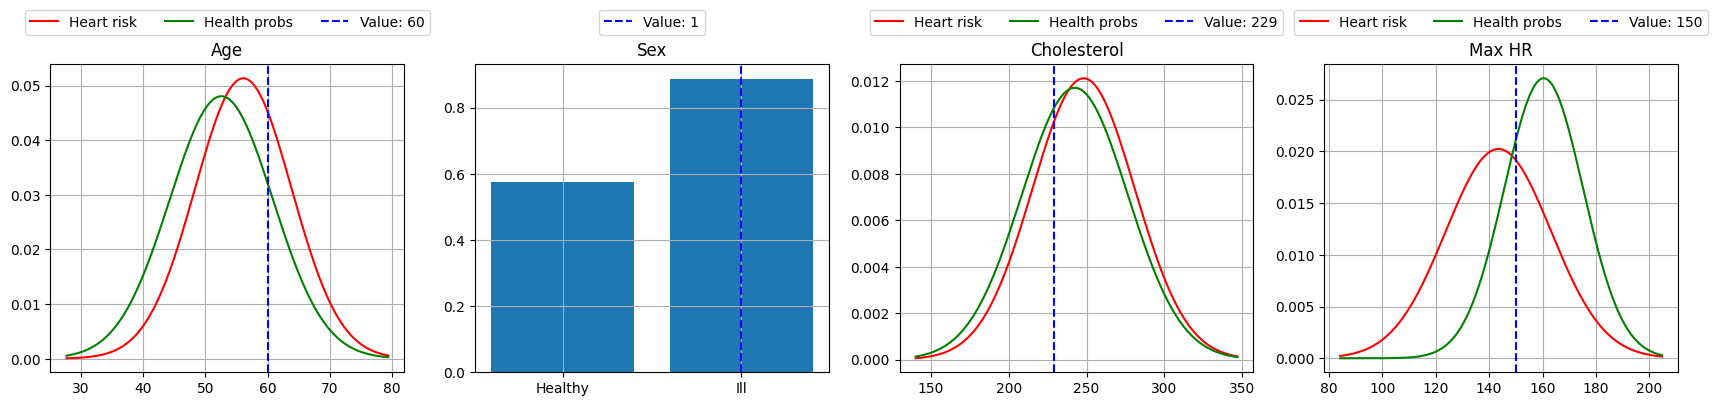

In [ ]:
b.predict({"Age": 60, "Sex": 1, "Cholesterol": 229, "Max HR": 150}, plot=True)

In [ ]:
b.predict({"Age": 60, "Sex": 1, "Cholesterol": 229, "Max HR": 150}, plot=False)

0.6026

In [ ]:
preds = []
for _, features in x_test.iterrows():
    pred = b.predict(features) > 0.5
    preds.append(pred)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       False       0.73      0.82      0.78     34819
        True       0.74      0.63      0.68     28181

    accuracy                           0.74     63000
   macro avg       0.74      0.73      0.73     63000
weighted avg       0.74      0.74      0.73     63000



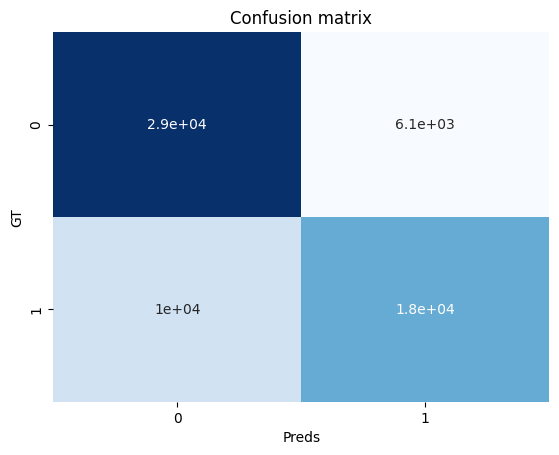

In [ ]:
conf_mat = confusion_matrix(y_test, preds)
sns.heatmap(conf_mat, cmap="Blues", cbar=False, annot=True)
plt.title("Confusion matrix")
plt.xlabel("Preds")
plt.ylabel("GT")
plt.show()